In [6]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import scipy.optimize as scippy
import scipy.stats as scist
from numpy.fft import fft, ifft
import os
import shutil
from numba import njit, prange
from scipy.integrate import quad

plt.rc("xtick", labelsize=20, top=True, direction="in")
plt.rc("ytick", labelsize=20, right=True, direction="in")
plt.rc("axes", titlesize=26)
plt.rc("axes", labelsize=26)
plt.rc("legend", fontsize=26)

In [7]:
# Simulation parameters
N = 50

sigma = 1.0
L = 10.0*sigma
rho = N/(L**2) # 2D

kappa = 1.0
r_cut = 6.0 / kappa

gamma = 1.0 # gamma=xi from previously

kBT = 1.0
V_0 = 1.0
U_0 = V_0 / kBT

F_D = 1 * kBT / sigma

tau = gamma * sigma**2 / V_0 # Time unit for everything
dt = 1e-4 * tau
t_equil = 10.0 * tau
t_prod = 10.0 * tau
# t_sim = t_equil + t_prod

n_steps_equil = int(t_equil / dt)
n_steps_prod = int(t_prod / dt)
n_steps = n_steps_equil + n_steps_prod

In [8]:
# Minimum image convention
@njit(fastmath=True)
def min_image(dx, L):
    return dx - L * np.round(dx / L)

# Might want to smoothe the cutoff later
@njit(fastmath=True)
def V_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma/r * np.exp( -kappa*(r-sigma) )
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Quotient rule derivative; double-check at some point
@njit(fastmath=True)
def F_Yuk(r):
    if 0 < r < r_cut:
        return V_0*sigma * np.exp( -kappa*(r-sigma) ) * (kappa*r + 1) / r**2
    elif r >= r_cut:
        return 0.0
    else:
        raise ValueError

# Intialize particles on a 2D grid, deleting some randomly if N isn't a square number
def init_grid(L, N):
    # Find smallest integer grid size n such that n^2 >= N
    n = int(np.ceil(np.sqrt(N)))

    # Build n×n grid
    coords = np.linspace(0.5*sigma, L - 0.5*sigma, n)
    X, Y= np.meshgrid(coords, coords, indexing='ij')
    pts = np.column_stack([X.ravel(), Y.ravel()])

    # Randomly choose exactly N points, implicitly deleting the rest by replace=False
    idx = np.random.choice(len(pts), N, replace=False)
    return pts[idx]

# Compute the forces using the Yukawa interaction AND the external driving
@njit(fastmath=True)
def compute_forces(pos):
    forces = np.zeros((N, 2))

    for i in range(N):
        xi, yi = pos[i]

        for j in range(i + 1, N): # <-- Only compute j > i to utilize the symmetry
            dx = min_image(xi - pos[j, 0], L)
            dy = min_image(yi - pos[j, 1], L)
            r = np.sqrt(dx*dx + dy*dy)

            F_mag = F_Yuk(r) # Magnitude of the force

            fx = F_mag * dx / r
            fy = F_mag * dy / r

            # Apply Newton's third law / symmetry of the force matrix:
            forces[i, 0] += fx
            forces[i, 1] += fy

            forces[j, 0] -= fx
            forces[j, 1] -= fy
            
    return forces

# Brownian Dynamics integration step
@njit(fastmath=True)
def bd_step(pos):
    F_matrix = compute_forces(pos)
    noise = np.sqrt(2 * kBT * dt / gamma) * np.random.normal(0.0, 1.0, (N, 2)) # Add thermal noise
    pos = pos + dt * F_matrix / gamma + noise # Update positions with forces and noise

    for i in range(N):
        pos[i,0] -= L * np.floor(pos[i,0] / L) # Apply periodic boundary conditions
        pos[i,1] -= L * np.floor(pos[i,1] / L)

    return pos

In [ ]:
pos = init_grid(L, N)

# Equilibrate
for step in range(n_steps_equil):
    pos = bd_step(pos)

# Plot positions, potentially w/o the equilibration above to check that everything works:
# fig, ax = plt.subplots(figsize=(5, 5))

# ax.scatter(pos[:, 0], pos[:, 1])
# ax.set_aspect('equal')
# fig.tight_layout()

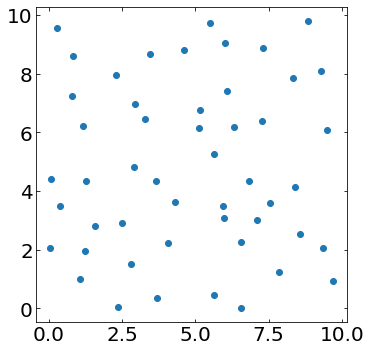

In [35]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(pos[:, 0], pos[:, 1])
ax.set_aspect('equal')
fig.tight_layout()